In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Import required libraries for simulation, data handling, and visualization

# Standard libraries for time handling
import datetime

# Data analysis and numerical computation
import pandas as pd          # structured data (tables, CSVs)
import numpy as np           # numerical operations and arrays

# Plotting and visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse   # used for dispersion ellipses

# RocketPy core simulation classes
from rocketpy import (
    Environment, Flight, Function, MonteCarlo, Rocket,
    SolidMotor, Fluid, CylindricalTank, MassFlowRateBasedTank,
    HybridMotor, GenericMotor
)

# RocketPy stochastic (Monte Carlo variation) components
from rocketpy.stochastic import (
    StochasticEnvironment,
    StochasticFlight,
    StochasticNoseCone,
    StochasticParachute,
    StochasticRailButtons,
    StochasticRocket,
    StochasticSolidMotor,
    StochasticTail,
    StochasticTrapezoidalFins,
    StochasticGenericMotor
)

# Geospatial raster handling (maps, terrain)
import rasterio
from rasterio.windows import from_bounds   # crop map regions

# Coordinate transformations (lat/lon ↔ projected coords)
from pyproj import Transformer

# Custom rocket simulation wrapper/module
from rocket_pams import rocket_sim

In [5]:
# Creating rocket simulation object
rs = rocket_sim()  
# This comes from our own file and has the rocket setup + functions we use to run simulations

In [6]:
# Path to thrust curve file
thrust_curve = '/Users/mariacuevas/Desktop/Rockets/Open Rocket/Q-8159_columbia-hybrid.rse'
# File that contains thrust vs time data for the motor (used in the simulation)

# Creating motor used for the simulation
deterministic_motor = rs.rocket_motor(thrust_curve)  

/opt/anaconda3/envs/rocketpy312/lib/python3.12/site-packages/rocketpy/motors/motor.py:990: UserWarning: burn_time argument (0, 12.7) is out of thrust source time range. Using thrust_source boundary times instead: (0, 12.335) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


#drogue+main

In [7]:
power_off_drag="/Users/mariacuevas/Desktop/Rockets/Files/drag_off.csv"

power_on_drag="/Users/mariacuevas/Desktop/Rockets/Files/drag_on.csv"

# Create rocket and its components
deterministic_rocket, rail_buttons, nose, trapezoidal_fins, tail, drogue, main = rs.rocket_body(deterministic_motor,power_off_drag,power_on_drag, 'nominal')
# We pass in: (motor, drag_off, drag_on, flight_type)

# Inputs:
# motor → motor used for the simulation

# power_off_drag → drag when motor is OFF
# (Rocket.power_off_drag: drag coefficient vs Mach when not thrusting)

# power_on_drag → drag when motor is ON
# (Rocket.power_on_drag: drag coefficient vs Mach during burn)

# flight_type → type of recovery scenario:
# 'nominal' → drogue + main both deploy  
# 'main_only' → only main deploys  
# 'drogue_only' → only drogue deploys  
# 'ballistic' → no parachutes (free fall)

In [8]:

# Running a single (deterministic) flight simulation
# "Deterministic" means everything is fixed (no randomness)
# Same inputs → same exact trajectory every time
# Used as a baseline before adding variability (Monte Carlo)

deterministic_flight = Flight(
    rocket=deterministic_rocket,
    environment=rs.env,
    rail_length=15.2,
    inclination=88,
    heading=210,
)

# rocket → rocket object we just built
# environment → weather + location conditions

# rail_length → launch rail length (meters), affects initial acceleration
# inclination → launch angle from horizontal (88° ≈ almost vertical)
# heading → launch heading angle relative to north given in degrees.

In [9]:
deterministic_flight.x_impact

np.float64(-4871.20441607034)

In [10]:
# Extract key motor and rocket parameters (baseline values)

tb_nom = deterministic_motor.burn_out_time
mp_nom = deterministic_motor.propellant_initial_mass
md_nom = deterministic_motor.dry_mass
x_cg = deterministic_motor.center_of_dry_mass_position
Im = deterministic_motor.total_impulse

x_cm_nom = deterministic_rocket.center_of_mass_without_motor

# These are the nominal (baseline) values from the deterministic setup
# We will vary these later to introduce uncertainty in the simulations

In [11]:

# Creating stochastic (randomized) motor based on the nominal one
stochastic_motor = StochasticGenericMotor(
    generic_motor=deterministic_motor,  

    # All parameters are defined as (mean, standard deviation)
    # → values are sampled from a Gaussian (normal) distribution

    # total impulse → (Im, 5% of Im)
    # 5% (1σ) spread represents realistic variability in motor performance
    total_impulse=(Im, 0.05 * Im),

    # burn start → (0 s, 0.02 s)
    # ignition timing jitter from electronics/igniter delays (1σ = 0.02 s)
    burn_start_time=(0.0, 0.02),

    # burn out time → (tb_nom, 0.05 s)
    # variation in burn duration due to combustion/regression differences
    burn_out_time=(tb_nom, 0.05),

    # propellant mass → (mp_nom, 3% of mp_nom)
    # accounts for casting tolerances and leftover/unburned propellant
    propellant_initial_mass=(mp_nom, 0.03 * mp_nom),

    # dry mass → (md_nom, 2% of md_nom)
    # reflects uncertainty in hardware/assembly mass
    dry_mass=(md_nom, 0.02 * md_nom),

    # center of dry mass → (x_cg, 0.002 m)
    # ~2 mm (1σ) uncertainty in internal mass placement
    center_of_dry_mass_position=(x_cg, 0.002)
)


# Create stochastic rocket (adds uncertainty to aerodynamic + mass properties)
stochastic_rocket = StochasticRocket(
    rocket=deterministic_rocket,

    # drag factors are multipliers: (mean=1, std deviation)
    # → scales the nominal drag curve

    # power-off drag → 10% (1σ)
    # aerodynamic uncertainty is one of the main drivers of landing spread
    power_off_drag_factor=(1.0, 0.10),

    # power-on drag → 15% (1σ)
    # higher uncertainty during burn due to flow complexity
    power_on_drag_factor=(1.0, 0.15),

    # center of mass → (x_cm_nom, 0.003 m)
    # ~3 mm (1σ) shift from integration/assembly tolerances
    center_of_mass_without_motor=(x_cm_nom, 0.003)
)


# Component-level uncertainties (also Gaussian, defined by std dev)

stochastic_rb = StochasticRailButtons(
    rail_buttons=rail_buttons,
    buttons_distance=0.001  # 1 mm (1σ) placement uncertainty
)

stochastic_nosecone = StochasticNoseCone(nosecone=nose)
# includes geometry/mass uncertainty handled internally

stochastic_t_fins = StochasticTrapezoidalFins(trapezoidal_fins=trapezoidal_fins)
# includes fin geometry + alignment uncertainty

stochastic_tails = StochasticTail(tail=tail)
# includes tail geometry uncertainty


# Overall idea:
# each run samples from these Gaussian distributions (1σ = values above)
# → produces slightly different trajectories → gives landing dispersion


In [12]:

stochastic_motor = StochasticGenericMotor(
    generic_motor=deterministic_motor,  # Nominal GenericMotor used as the baseline for Monte Carlo

    # Total impulse uncertainty:
    # Modeled as a Gaussian distribution with 5% (1σ) standard deviation.
    # This captures variability in propellant mass, combustion efficiency,
    # and manufacturing tolerances typical of student-built motors.
    total_impulse=(Im, 0.05 * Im),

    # Burn start time uncertainty:
    # Models ignition timing jitter due to igniter and electrical delays.
    # Mean ignition time is 0 s, with a 1σ uncertainty of 0.02 s.
    burn_start_time=(0.0, 0.02),

    # Burn out time uncertainty:
    # Captures small variations in burn duration caused by regression rate
    # differences and chamber pressure variability.
    burn_out_time=(tb_nom, 0.05),

    # Propellant mass uncertainty:
    # Accounts for casting tolerances, voids, and residual propellant.
    # Modeled as a 3% (1σ) Gaussian uncertainty.
    propellant_initial_mass=(mp_nom, 0.03 * mp_nom),

    # Dry mass uncertainty:
    # Captures manufacturing and assembly tolerances in the motor hardware.
    # Modeled as a 2% (1σ) Gaussian uncertainty.
    dry_mass=(md_nom, 0.02 * md_nom),

    # Center of dry mass position uncertainty:
    # Represents uncertainty in internal component placement and measurement
    # ±2 mm (1σ) is typical for student-built hardware.
    center_of_dry_mass_position=(x_cg, 0.002)
)




stochastic_rocket = StochasticRocket(
    rocket=deterministic_rocket,

    # Aerodynamic uncertainty (dominant source of dispersion)
    power_off_drag_factor=(1.0, 0.10),  # 10% (1σ)
    power_on_drag_factor=(1.0, 0.15),   # 15% (1σ)
 
    # Structural / integration uncertainty
    center_of_mass_without_motor=(x_cm_nom, 0.003)
)

stochastic_rb=StochasticRailButtons(rail_buttons=rail_buttons,buttons_distance=0.001)
stochastic_nosecone=StochasticNoseCone(nosecone=nose)
stochastic_t_fins=StochasticTrapezoidalFins(trapezoidal_fins=trapezoidal_fins)
stochastic_tails=StochasticTail(tail=tail)





In [13]:
# Adding uncertainty to parachute behavior

stochastic_drogue = StochasticParachute(
    parachute=drogue,

    # cd_s → (mean, std dev)
    # 10% (1σ) uncertainty in Cd*S (drag area)
    # captures variability in inflation, packing, and deployment conditions
    cd_s=(rs.cd_s_drogue, 0.1 * rs.cd_s_drogue),

    # lag → (mean, std dev)
    # delay between trigger and full deployment
    # 1 s nominal with 0.2 s (1σ) spread
    lag=(1.0, 0.2)
)


stochastic_main = StochasticParachute(
    parachute=main,

    # same idea for main parachute
    cd_s=(rs.cd_s_main, 0.1 * rs.cd_s_main),

    # deployment delay uncertainty
    # 1 s nominal with 0.2 s (1σ)
    lag=(1.0, 0.2)
)


# Both cd_s and lag are sampled from Gaussian distributions
# → affects descent rate and landing location

In [14]:
# Attaching all stochastic components to the rocket

stochastic_rocket.add_motor(stochastic_motor)
# adds the motor with its uncertainty distributions

stochastic_rocket.add_nose(stochastic_nosecone)
# includes nose geometry/mass uncertainty

stochastic_rocket.add_trapezoidal_fins(stochastic_t_fins)
# includes fin geometry/alignment uncertainty

stochastic_rocket.add_tail(stochastic_tails)
# includes tail section uncertainty

stochastic_rocket.set_rail_buttons(
    stochastic_rb, lower_button_position=(0.001, "normal")
)
# sets rail button positions with uncertainty
# lower_button_position → reference position along the rocket

stochastic_rocket.add_parachute(stochastic_main)
stochastic_rocket.add_parachute(stochastic_drogue)
# adds both parachutes with CdS + lag uncertainty


# At this point:
# the rocket is fully defined with all uncertainties included
# → ready for Monte Carlo simulations

In [15]:
# Create stochastic flight (adds uncertainty to flight conditions)

stochastic_flight = StochasticFlight(
    flight=deterministic_flight,

    # inclination → (mean, std dev)
    # varies launch angle around 88° with 0.1° (1σ)
    inclination=(88, 0.1)
)

In [16]:
# Creating stochastic environment (adds uncertainty to wind conditions)

stochastic_env = StochasticEnvironment(
    environment=rs.env,

    # wind factors → (mean, std dev)
    # scales the wind profile in x and y directions

    # wind_velocity_x_factor → varies wind in x-direction
    # 25% (1σ) uncertainty → captures forecast error in wind speed
    wind_velocity_x_factor=(1.0, 0.25),

    # wind_velocity_y_factor → varies wind in y-direction
    # same 25% (1σ) uncertainty
    wind_velocity_y_factor=(1.0, 0.25),
)

In [17]:
# Defining function to compute longitudinal moment from flight data

def longitudinal_moment(flight):
    M_pitch = flight.M2[:, 1]  # pitch moment over time
    M_yaw   = flight.M3[:, 1]  # yaw moment over time

    # combining pitch and yaw moments (vector magnitude) and take max value
    return np.max(np.sqrt(M_pitch**2 + M_yaw**2))


# Storing custom output to track during Monte Carlo
custom_data_collector = {
    "longitudinal_moment": longitudinal_moment,
}
# this lets us save the max combined moment for each simulation run

In [28]:
# Setting up Monte Carlo simulation for landing dispersion

dispersion = MonteCarlo(
    filename="landing_dispersion",

    # stochastic inputs (all include uncertainty distributions)
    environment=stochastic_env,
    rocket=stochastic_rocket,
    flight=stochastic_flight,

    # custom outputs to track for each run
    data_collector=custom_data_collector
)

# Monte Carlo → runs many simulations with random samples from the distributions
# each run is slightly different → gives spread in landing locations (dispersion)
# results are saved under the given filename

The following input file was imported: landing_dispersion.inputs.txt
A total of 20 simulations results were loaded from the following output file: landing_dispersion.outputs.txt

The following error file was imported: landing_dispersion.errors.txt                                         


In [29]:
# Run Monte Carlo simulations

dispersion.simulate(
    number_of_simulations=500,   # total number of runs (each run samples new random values)

    append=False,               # overwrite previous results (do not add to existing file)

    include_function_data=False,# do not store full time-series (saves memory, only key outputs)

    parallel=True,              # run simulations in parallel
    n_workers=10                # number of CPU workers used
)

# runs 500 different trajectories with sampled uncertainties
# → builds landing dispersion statistics

Starting Monte Carlo analysis                                       
Running Monte Carlo simulation with 8 workers.


Current iteration: 000499 | Average Time per Iteration: 0.469 s | Estimated time left: 0 s  
Completed 500 iterations. In total, 500 simulations are exported.
Total wall time: 234.4 s
Results saved to landing_dispersion.outputs.txt


In [20]:
# Printing summary statistics of Monte Carlo results

dispersion.info()

Monte Carlo Simulation by RocketPy
Data Source:  landing_dispersion
Number of simulations:  20
Results: 

                Parameter            Mean          Median       Std. Dev.    95% PI Lower    95% PI Upper
--------------------------------------------------------------------------------------------------------------
                 y_impact       -7920.326       -8108.904        1566.042      -10727.182       -4910.854
 initial_stability_margin           2.220           2.210           0.075           2.119           2.386
     frontal_surface_wind           0.004          -0.008           0.210          -0.382           0.360
              apogee_time          60.426          60.140           3.189          55.383          65.990
                 apogee_y        -553.890        -489.120         231.084       -1021.938        -221.016
                 x_impact       -4780.770       -4561.932        1273.484       -7087.053       -2929.858
out_of_rail_stability_margin           2.

In [30]:
# Setingt output filename (Monte Carlo automatically appends .outputs.txt)
filename = "landing_dispersion.outputs.txt"
# results will always be stored as: <filename>.outputs.txt
'''
from earlier
dispersion = MonteCarlo(
    filename="<filename>",


    environment=stochastic_env,
    rocket=stochastic_rocket,
    flight=stochastic_flight,

    data_collector=custom_data_collector
)
'''

# Initializing storage for results
dispersion_general_results = []
# list of full dictionaries (one per simulation)

dispersion_results = {
    "out_of_rail_time": [],
    "out_of_rail_velocity": [],
    "apogee_time": [],
    "apogee_altitude": [],
    "apogee_x": [],
    "apogee_y": [],
    "impact_time": [],
    "x_impact": [],
    "y_impact": [],
    "impact_velocity": [],
    "initial_static_margin": [],
    "out_of_rail_static_margin": [],
    "final_static_margin": [],
    "number_of_events": [],
    "max_velocity": [],
    "drogue_triggerTime": [],
    "drogue_inflated_time": [],
    "drogue_inflated_velocity": [],
    "execution_time": [],
    "longitudinal_moment": [],
}
# dictionary of lists → each key stores values across all simulations


# Open Monte Carlo output file
dispersion_output_file = open(str(filename), "r+")
# file contains one dictionary per simulation (one per line)


# Read file line by line
for line in dispersion_output_file:

    # skip lines that are not data (comments / headers)
    if line[0] != "{":
        continue

    # convert string → dictionary
    flight_result = eval(line)

    # store full result
    dispersion_general_results.append(flight_result)

    # extract each parameter into its own list
    for parameter_key in dispersion_results.keys():
        if parameter_key in flight_result:
            dispersion_results[parameter_key].append(flight_result[parameter_key])


# Close file after reading
dispersion_output_file.close()


# Total number of simulations loaded
N = len(dispersion_general_results)
print("Number of simulations: ", N)


# At this point:
# dispersion_general_results → full data per run
# dispersion_results → easy access to each variable across all runs

Number of simulations:  500


In [31]:
label = "Main + Drogue"  # label for this case (recovery configuration)

# Get longitudinal moment values from Monte Carlo
loads = np.array(dispersion_results["longitudinal_moment"])  # convert list → array for calculations

# Mean and standard deviation of the distribution
mean = np.mean(loads)  # average longitudinal moment
std  = np.std(loads)   # spread of the values (1σ)

# Identify values within 2σ of the mean
inside_2sigma = np.abs(loads - mean) <= 2 * std  # keeps values within mean ± 2σ

loads_2sigma = loads[inside_2sigma]  # filtered data (removes extreme outliers)

# Maximum longitudinal moment within 2σ range
largest_within_2sigma = np.max(loads_2sigma)  # representative worst-case load

print(f"--- {label} ---")
print(f"Largest longitudinal moment inside 2σ: {largest_within_2sigma:,.1f} N·m")


'''Longitudinal moment was asked about in the progress report 
and refers to the combined pitch and yaw moment acting on the rocket, 
representing the torque that tries to rotate it away from its flight direction'''

--- Main + Drogue ---
Largest longitudinal moment inside 2σ: 191.0 N·m


'Longitudinal moment was asked about in the progress report \nand refers to the combined pitch and yaw moment acting on the rocket, \nrepresenting the torque that tries to rotate it away from its flight direction'

In [32]:
# Monte Carlo impacts (landing positions)
impact_x = np.array(dispersion_results["x_impact"])
impact_y = np.array(dispersion_results["y_impact"])
# arrays of landing coordinates from all simulations

# Deterministic impact (single baseline trajectory)
det_x = deterministic_flight.x_impact
det_y = deterministic_flight.y_impact

# Creating DataFrame for Monte Carlo results
df_mc = pd.DataFrame({
    "type": "monte_carlo",
    "impact_x_m": impact_x,
    "impact_y_m": impact_y
})

# Creating DataFrame for deterministic result
df_det = pd.DataFrame({
    "type": ["deterministic"],
    "impact_x_m": [det_x],
    "impact_y_m": [det_y]
})

# Combining both into one dataset
df_all = pd.concat([df_mc, df_det], ignore_index=True)

# Saving to CSV file
df_all.to_csv("main_drogue_impacts_uw.csv", index=False)
# stores x and y impact points → used later to plot landing dispersion

print("Saved to main_drogue_impacts_uw.csv")

Saved to main_drogue_impacts_uw.csv


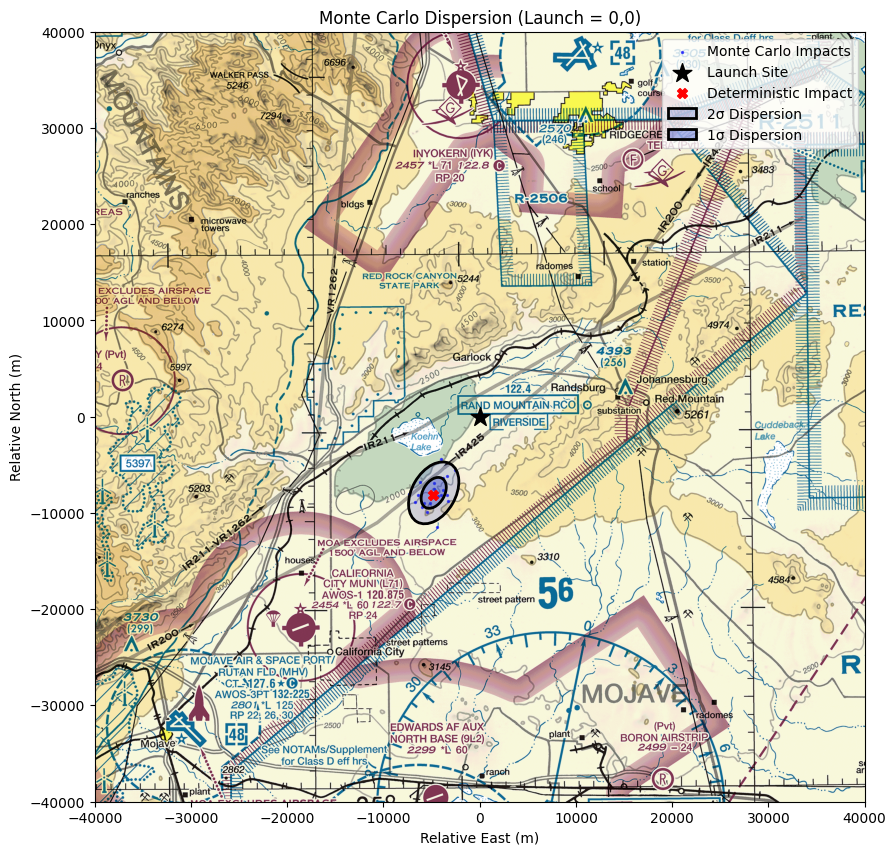

In [25]:
# ============================================
# SECTIONAL MAP + MONTE CARLO
# Axes in meters, Launch = (0,0)
# 1σ and 2σ ellipses
# ============================================

sectional_path = "Los Angeles SEC.tif"  # sectional map file is specified

fig, ax = plt.subplots(figsize=(10,10))  # square plotting area is created

with rasterio.open(sectional_path) as src:

    # Launch coordinates are converted from lat/lon to projected meters
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    launch_x_abs, launch_y_abs = transformer.transform(rs.long, rs.lat)

    buffer = 40000  # a 40 km window around launch is defined

    # Bounds of the map region are set around the launch location
    min_x = launch_x_abs - buffer
    max_x = launch_x_abs + buffer
    min_y = launch_y_abs - buffer
    max_y = launch_y_abs + buffer

    # Raster is cropped to the region of interest
    window = from_bounds(min_x, min_y, max_x, max_y, src.transform)

    band = src.read(1, window=window)     # raster data is read
    colormap = src.colormap(1)            # color mapping is retrieved
    transform = src.window_transform(window)  # spatial transform is obtained


# Indexed raster values are converted to RGB image
rgb = np.zeros((band.shape[0], band.shape[1], 3), dtype=np.uint8)

for key, value in colormap.items():
    rgb[band == key] = value[:3]  # RGB values are assigned


# Absolute map extent is computed in projected coordinates
left = transform.c
top = transform.f
right = left + transform.a * band.shape[1]
bottom = top + transform.e * band.shape[0]
extent_abs = [left, right, bottom, top]


# Coordinates are shifted so that launch is at (0,0)
extent_rel = [
    extent_abs[0] - launch_x_abs,
    extent_abs[1] - launch_x_abs,
    extent_abs[2] - launch_y_abs,
    extent_abs[3] - launch_y_abs
]


# Sectional map is plotted
ax.imshow(rgb, extent=extent_rel)


# ============================================
# Monte Carlo (relative coordinates)
# ============================================

# Landing positions from Monte Carlo are extracted
impact_x_rel = np.array(dispersion_results["x_impact"])
impact_y_rel = np.array(dispersion_results["y_impact"])

# Launch is defined as the origin
launch_x = 0
launch_y = 0


# All impact points are plotted
ax.scatter(
    impact_x_rel,
    impact_y_rel,
    s=2,
    color="blue",
    alpha=0.6,
    label="Monte Carlo Impacts"
)

# Launch location is plotted
ax.scatter(
    launch_x,
    launch_y,
    s=200,
    marker="*",
    color="black",
    zorder=5,
    label="Launch Site"
)
# Deterministic landing
det_x_rel = deterministic_flight.x_impact
det_y_rel = deterministic_flight.y_impact

# Deterministic landing point is plotted
ax.scatter(
    det_x_rel, det_y_rel,
    s=50,
    marker="X",
    color="red",
    label="Deterministic Impact",
    zorder=5
)


# ============================================
# Covariance & Eigenvalues
# ============================================

# Covariance matrix of impact positions is computed
cov = np.cov(impact_x_rel, impact_y_rel)

# Eigenvalues and eigenvectors are computed
vals, vecs = np.linalg.eigh(cov)

# Eigenvalues are sorted (largest first)
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

# Rotation angle of ellipse is computed
theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

# Center of dispersion is computed
center_x = impact_x_rel.mean()
center_y = impact_y_rel.mean()


# ============================================
# 1σ Ellipse
# ============================================

# 1σ ellipse is created using covariance
ellipse_1 = Ellipse(
    (center_x, center_y),
    2 * np.sqrt(vals[0]),   # width = 2 * 1σ
    2 * np.sqrt(vals[1]),   # height = 2 * 1σ
    angle=theta,
    facecolor=(0.1, 0.2, 0.8, 0.35),
    edgecolor="black",
    linewidth=2,
    label="1σ Dispersion"
)


# ============================================
# 2σ Ellipse
# ============================================

# 2σ ellipse is created using scaled covariance
ellipse_2 = Ellipse(
    (center_x, center_y),
    4 * np.sqrt(vals[0]),   # width = 2 * 2σ
    4 * np.sqrt(vals[1]),   # height = 2 * 2σ
    angle=theta,
    facecolor=(0.1, 0.2, 0.8, 0.18),
    edgecolor="black",
    linewidth=2,
    label="2σ Dispersion"
)

# Larger ellipse is drawn first
ax.add_patch(ellipse_2)

# Smaller ellipse is drawn on top
ax.add_patch(ellipse_1)


# ============================================
# Final Formatting
# ============================================

# Plot limits are set to match map extent
ax.set_xlim(extent_rel[0], extent_rel[1])
ax.set_ylim(extent_rel[2], extent_rel[3])

# Aspect ratio is enforced to keep distances correct
ax.set_aspect("equal")

# Axis labels and title are set
ax.set_xlabel("Relative East (m)")
ax.set_ylabel("Relative North (m)")
ax.set_title("Monte Carlo Dispersion (Launch = 0,0)")

# Legend is displayed
ax.legend()

# Plot is shown
plt.show()

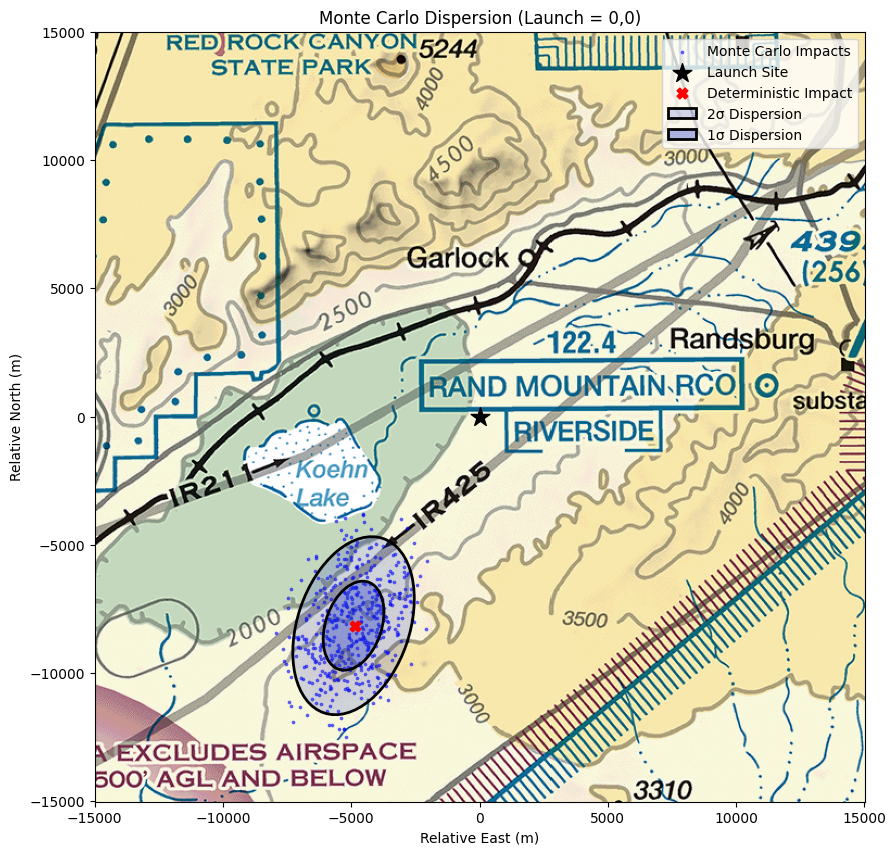

In [33]:
# ============================================
# MONTE CARLO DISPERSION + SECTIONAL MAP
# Launch = (0,0), axes in meters
# 1σ and 2σ ellipses
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer

# ============================================
# Monte Carlo (relative coordinates)
# ============================================

impact_x_rel = np.array(dispersion_results["x_impact"])
impact_y_rel = np.array(dispersion_results["y_impact"])

# --------------------------------------------
# Optional: remove extreme outliers (important)
# --------------------------------------------

coords = np.vstack([impact_x_rel, impact_y_rel])
cov_initial = np.cov(coords)
inv_cov = np.linalg.inv(cov_initial)

mean = coords.mean(axis=1, keepdims=True)
diff = coords - mean

# Mahalanobis distance
d2 = np.einsum("ij,jk,ik->i", diff.T, inv_cov, diff.T)

# keep points inside ~2σ (95%)
mask = d2 < 6.0

impact_x_rel = impact_x_rel[mask]
impact_y_rel = impact_y_rel[mask]

# ============================================
# Covariance & Eigenvalues
# ============================================

cov = np.cov(impact_x_rel, impact_y_rel)

vals, vecs = np.linalg.eigh(cov)

order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]

theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

center_x = impact_x_rel.mean()
center_y = impact_y_rel.mean()

# --------------------------------------------
# Data-driven zoom (fixes huge map issue)
# --------------------------------------------

spread = 2 * np.sqrt(np.max(vals))   # characteristic scale
buffer = max(15000, 4 * spread)     # min 15 km or data-driven

# ============================================
# Load Sectional Map (cropped to dispersion)
# ============================================

sectional_path = "Los Angeles SEC.tif"

with rasterio.open(sectional_path) as src:

    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    launch_x_abs, launch_y_abs = transformer.transform(rs.long, rs.lat)

    min_x = launch_x_abs - buffer
    max_x = launch_x_abs + buffer
    min_y = launch_y_abs - buffer
    max_y = launch_y_abs + buffer

    window = from_bounds(min_x, min_y, max_x, max_y, src.transform)

    band = src.read(1, window=window)
    colormap = src.colormap(1)
    transform = src.window_transform(window)

# --------------------------------------------
# Convert indexed raster → RGB
# --------------------------------------------

rgb = np.zeros((band.shape[0], band.shape[1], 3), dtype=np.uint8)

for key, value in colormap.items():
    rgb[band == key] = value[:3]

# --------------------------------------------
# Compute relative extent (launch = 0,0)
# --------------------------------------------

left = transform.c
top = transform.f
right = left + transform.a * band.shape[1]
bottom = top + transform.e * band.shape[0]

extent_abs = [left, right, bottom, top]

extent_rel = [
    extent_abs[0] - launch_x_abs,
    extent_abs[1] - launch_x_abs,
    extent_abs[2] - launch_y_abs,
    extent_abs[3] - launch_y_abs
]

# ============================================
# Plot
# ============================================

fig, ax = plt.subplots(figsize=(10,10))

# Map
ax.imshow(rgb, extent=extent_rel)

# Monte Carlo points
ax.scatter(
    impact_x_rel,
    impact_y_rel,
    s=3,
    color="blue",
    alpha=0.5,
    label="Monte Carlo Impacts"
)

# Launch
ax.scatter(
    0, 0,
    s=200,
    marker="*",
    color="black",
    zorder=5,
    label="Launch Site"
)

# Deterministic impact
det_x_rel = deterministic_flight.x_impact
det_y_rel = deterministic_flight.y_impact

ax.scatter(
    det_x_rel,
    det_y_rel,
    s=60,
    marker="X",
    color="red",
    zorder=5,
    label="Deterministic Impact"
)

# ============================================
# Ellipses (1σ and 2σ)
# ============================================

ellipse_1 = Ellipse(
    (center_x, center_y),
    2 * np.sqrt(vals[0]),
    2 * np.sqrt(vals[1]),
    angle=theta,
    facecolor=(0.1, 0.2, 0.8, 0.35),
    edgecolor="black",
    linewidth=2,
    label="1σ Dispersion"
)

ellipse_2 = Ellipse(
    (center_x, center_y),
    4 * np.sqrt(vals[0]),
    4 * np.sqrt(vals[1]),
    angle=theta,
    facecolor=(0.1, 0.2, 0.8, 0.18),
    edgecolor="black",
    linewidth=2,
    label="2σ Dispersion"
)

ax.add_patch(ellipse_2)
ax.add_patch(ellipse_1)

# ============================================
# Final formatting
# ============================================

ax.set_xlim(extent_rel[0], extent_rel[1])
ax.set_ylim(extent_rel[2], extent_rel[3])

ax.set_aspect("equal")

ax.set_xlabel("Relative East (m)")
ax.set_ylabel("Relative North (m)")
ax.set_title("Monte Carlo Dispersion (Launch = 0,0)")

ax.legend()

# --------------------------------------------
# Save figure
# --------------------------------------------

plt.savefig(
    "dispersion_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()